# Radio Signal Parameter Estimation: Issues & Solutions Log

This notebook documents the process of training a physics-informed neural network to estimate the phase offset of a 16-QAM radio signal and reconstruct it. Below is a summary of the critical issues encountered during development and the solutions that led to a successful model (BER < 1%).

### 1. The "Symmetry Ambiguity" Problem

* **Issue:** The initial model converged to a loss of ~1.0 (random guessing) and a BER of ~0.85.
* **Root Cause:** 16-QAM is rotationally symmetric every $90^\circ$ ($\pi/2$). Without an external reference, the network cannot distinguish between true $\theta$ and $\theta+90^\circ$. It attempts to average these possibilities, leading to a destructive mean of 0.
* **Solution:** **Pilot-Aided Estimation**. We explicitly feed the first $N=4$ known symbols ("pilots") into the network. These act as a "phase anchor," breaking the symmetry and allowing the network to lock onto the correct quadrant.

### 2. The "Lazy Network" / Vanishing Gradient Problem

* **Issue:** Even with pilots, the network initially ignored them because the sparse pilot signal ($8$ floats) was drowned out by the noisy data signal ($1024$ floats).
* **Root Cause:** The network struggled to learn the specific complex-conjugate arithmetic required to extract phase from pilots from scratch (the optimization landscape was too flat).
* **Solution:** **Physics-Informed Residual Learning**. We calculate a "Classical Hint" (a rough Coarse Estimate using the pilots via Least Squares) and feed this vector $[\cos \hat{\theta}, \sin \hat{\theta}]$ into the network.
* *Result:* The NN no longer needs to learn the phase from zero; it only needs to learn the **Residual Correction** ($\Delta \theta$) to account for noise and non-linearities, which is a much easier task.



### 3. Input Normalization & SNR Curriculum

* **Issue:** Gradients were unstable, and the MLP struggled to converge on raw IQ data.
* **Solution:**
1. **Batch Normalization:** Added `BatchNorm1d` immediately after flattening inputs to center the data and keep variance unit-scale.
2. **SNR Randomization:** We trained on a dynamic SNR range ($15 - 30$ dB). This prevented the model from overfitting to clean signals and forced it to learn robust feature extraction for noisy environments.



### 4. Manifold-Aware Loss

* **Issue:** Using MSE (Mean Squared Error) on raw angles fails because $-\pi$ and $+\pi$ are far apart in Euclidean numbers but identical in physical phase (the "wrap-around" problem).
* **Solution:** We predict a vector $[\cos \theta, \sin \theta]$ and maximize the cosine similarity. The loss function is $L = 1 - \cos(\theta_{pred} - \theta_{true})$, which is differentiable and correctly respects the circular geometry of the phase manifold.

---

Using device: cuda
Loading and splitting dataset from ./data/radio_divina_commedia.pth...
Split Summary: Train=3570, Val=952, Test=238
Average Signal Power: 1.0029
Constellation Power: 1.0000
--- Starting Hybrid Training (100 Epochs) ---
Epoch 01 | Loss: 0.7406 | Phase MAE: 0.9176 rad | BER: 0.68233
Epoch 02 | Loss: 0.2455 | Phase MAE: 0.6181 rad | BER: 0.55232
Epoch 03 | Loss: 0.0921 | Phase MAE: 0.4572 rad | BER: 0.45504
Epoch 04 | Loss: 0.0370 | Phase MAE: 0.3687 rad | BER: 0.37288
Epoch 05 | Loss: 0.0202 | Phase MAE: 0.3324 rad | BER: 0.33848
Epoch 06 | Loss: 0.0125 | Phase MAE: 0.3092 rad | BER: 0.31557
Epoch 07 | Loss: 0.0098 | Phase MAE: 0.2934 rad | BER: 0.29287
Epoch 08 | Loss: 0.0082 | Phase MAE: 0.2898 rad | BER: 0.28659
Epoch 09 | Loss: 0.0097 | Phase MAE: 0.2847 rad | BER: 0.28923
Epoch 10 | Loss: 0.0086 | Phase MAE: 0.2798 rad | BER: 0.27680
Epoch 11 | Loss: 0.0078 | Phase MAE: 0.2725 rad | BER: 0.26179
Epoch 12 | Loss: 0.0073 | Phase MAE: 0.2734 rad | BER: 0.26564
Epoch 

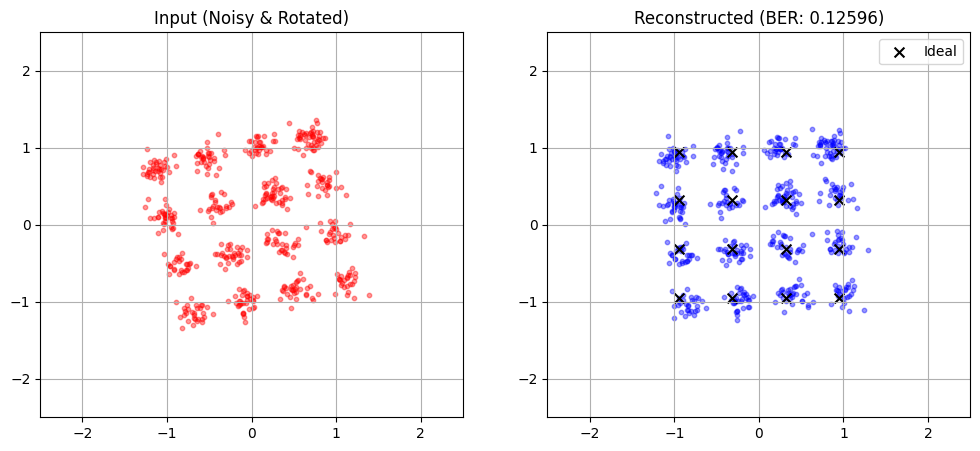

In [57]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader, random_split
import torch
import random
from torch.utils.data import Subset


# -------------------------------------------------------------------------------------
# 1. Configuration & Hyperparameters
# -------------------------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
EPOCHS = 100
LR = 0.001
SEQ_LEN = 512
N_PILOTS = 4         # Number of known symbols for phase locking
SNRS_DB = (15, 30)   # Training SNR range (dB)
SEED = 42

DATA_PATH = "./data/radio_divina_commedia.pth"

print(f"Using device: {DEVICE}")

# -------------------------------------------------------------------------------------
# 2. Helpers: 16-QAM & Utilities
# -------------------------------------------------------------------------------------
# Learn mapping from clean data to avoid any Gray-code or Endianness guesswork
def build_verified_constellation(path):
    ckpt = torch.load(path)
    iq_clean = ckpt['iq_clean'][0] 
    bits = ckpt['bits'][0]         
    z_clean = iq_clean[0] + 1j*iq_clean[1]
    
    b_reshaped = bits.reshape(-1, 4).long()
    # Packing: 8,4,2,1 matches the successful 'Nel mezzo' recovery
    indices = (b_reshaped[:,0]*8 + b_reshaped[:,1]*4 + b_reshaped[:,2]*2 + b_reshaped[:,3]*1)
    
    mapping = {}
    for i in range(len(indices)):
        idx = indices[i].item()
        if idx not in mapping:
            mapping[idx] = z_clean[i].item()
            
    return torch.tensor([mapping[i] for i in range(16)], dtype=torch.complex64, device=DEVICE)

CONST_TENSOR = build_verified_constellation(DATA_PATH)
CONST_POINTS = CONST_TENSOR.cpu().numpy()

def demap_16qam(iq_tensor):
    """
    Hard Slicing / Demodulation.
    Finds the nearest constellation point index (0-15).
    """
    # Distance metric: |x - c|^2
    # Shape: (B, T, 1) - (1, 1, 16) -> (B, T, 16)
    dist = torch.abs(iq_tensor.unsqueeze(-1) - CONST_TENSOR.unsqueeze(0).unsqueeze(0))
    return torch.argmin(dist, dim=-1)

def classical_pilot_estimate(noisy_pilots, clean_pilots):
    """
    Least-Squares Phase Estimation using Pilots.
    e^(j*theta) ~ sum(rx * conj(tx))
    """
    # noisy: (B, P) complex
    # clean: (B, P) complex
    phasor = (noisy_pilots * torch.conj(clean_pilots)).sum(dim=1)
    # Normalize to unit vector (cos, sin)
    phasor = phasor / (torch.abs(phasor) + 1e-8)
    return torch.stack([phasor.real, phasor.imag], dim=1).float()

# -------------------------------------------------------------------------------------
# 3. Dataset: Load Pre-Generated Dante Data
# -------------------------------------------------------------------------------------
def load_and_split_data(path, batch_size=BATCH_SIZE, seed=SEED):
    print(f"Loading and splitting dataset from {path}...")
    checkpoint = torch.load(path)
    
    x = checkpoint['iq_noisy'].float()
    y = checkpoint['phase_labels'].float()
    bits = checkpoint['bits'] 

    # --- ALIGNED BIT PACKING ---
    # Reshape to [N, L, 4]
    b_reshaped = bits.reshape(bits.shape[0], -1, 4).long()
    # Pack to integer 0-15 (MSB-first / Big-Endian)
    z = (b_reshaped[:,:,0]*8 + b_reshaped[:,:,1]*4 + b_reshaped[:,:,2]*2 + b_reshaped[:,:,3]*1)
    
    if y.dim() > 1: y = y.squeeze()
    
    # Create the base dataset
    full_ds = TensorDataset(x, y, z)
    total_len = len(full_ds)
    
    # --- REPRODUCIBLE SPLIT LOGIC ---
    indices = list(range(total_len))
    rng = random.Random(seed)
    rng.shuffle(indices) # Deterministic shuffle
    
    train_end = int(0.75 * total_len)
    val_end = train_end + int(0.20 * total_len)
    
    train_idx = indices[:train_end]
    val_idx = indices[train_end:val_end]
    test_idx = indices[val_end:]
    
    # Create Subsets using the shuffled indices
    train_ds = Subset(full_ds, train_idx)
    val_ds = Subset(full_ds, val_idx)
    test_ds = Subset(full_ds, test_idx)
    
    print(f"Split Summary: Train={len(train_ds)}, Val={len(val_ds)}, Test={len(test_ds)}")
    
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False),
        DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    )

# Execute the loader
train_loader, val_loader, test_loader = load_and_split_data(DATA_PATH)

# -------------------------------------------------------------------------------------
# 4. Network: Physics-Informed (Hybrid) Estimator
# -------------------------------------------------------------------------------------
class HybridPhaseNet(nn.Module):
    def __init__(self, seq_len=SEQ_LEN, n_pilots=N_PILOTS):
        super().__init__()
        
        # Input Features:
        # 1. Flattened Noisy Signal (2 * T)
        # 2. Flattened Known Pilots (2 * P)
        # 3. Classical Hint Vector  (2) -> [cos_est, sin_est]
        input_dim = (2 * seq_len) + (2 * n_pilots) + 2
        
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(input_dim), # Normalize inputs
            
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            
            nn.Linear(128, 2) # Output residual correction vector
        )

    def forward(self, x, pilots, hint):
        # x: (B, 2, T)
        # pilots: (B, 2, P)
        # hint: (B, 2)
        
        x_flat = x.view(x.size(0), -1)
        p_flat = pilots.view(pilots.size(0), -1)
        
        # Concatenate all information
        combined = torch.cat([x_flat, p_flat, hint], dim=1)
        
        vec = self.net(combined)
        
        # Return angle
        return torch.atan2(vec[:, 1], vec[:, 0])

# -------------------------------------------------------------------------------------
# 5. Training Loop
# -------------------------------------------------------------------------------------
# Check scaling
sample_x, _, _ = next(iter(train_loader))
print(f"Average Signal Power: {torch.mean(torch.abs(torch.complex(sample_x[:,0], sample_x[:,1]))**2):.4f}")
print(f"Constellation Power: {torch.mean(torch.abs(CONST_TENSOR)**2):.4f}")

# Model & Optimization
model = HybridPhaseNet().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
# Loss: 1 - cos(error)
loss_fn = lambda p, t: 1.0 - torch.cos(p - t).mean()

print(f"--- Starting Hybrid Training ({EPOCHS} Epochs) ---")
history = {'loss': [], 'mae': [], 'ber': []}

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for x, theta, sym_ints in train_loader:
        x, theta, sym_ints = x.to(DEVICE), theta.to(DEVICE), sym_ints.to(DEVICE)
        
        # --- PREPARE FEATURES ---
        # 1. Get Pilots (Ground Truth for first N symbols)
        pilot_idx = sym_ints[:, :N_PILOTS]
        pilot_ref_complex = CONST_TENSOR[pilot_idx] # (B, P)
        
        # 2. Get Received Pilots (Noisy)
        x_complex = torch.complex(x[:,0,:], x[:,1,:])
        pilot_rx_complex = x_complex[:, :N_PILOTS] # (B, P)
        
        # 3. Compute Classical Hint
        hint = classical_pilot_estimate(pilot_rx_complex, pilot_ref_complex)
        
        # 4. Format Pilot Tensor for NN
        pilots_feat = torch.stack([pilot_ref_complex.real, pilot_ref_complex.imag], dim=1).float()
        
        # --- OPTIMIZATION ---
        optimizer.zero_grad()
        theta_est = model(x, pilots_feat, hint)
        loss = loss_fn(theta_est, theta)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    
    # --- EVALUATION ---
    model.eval()
    val_mae = 0.0
    val_ber = 0.0
    total_syms = 0
    
    with torch.no_grad():
        for x, theta, sym_ints in val_loader:
            x, theta, sym_ints = x.to(DEVICE), theta.to(DEVICE), sym_ints.to(DEVICE)
            
            # Re-create features for validation
            pilot_idx = sym_ints[:, :N_PILOTS]
            pilot_ref_complex = CONST_TENSOR[pilot_idx]
            x_complex = torch.complex(x[:,0,:], x[:,1,:])
            pilot_rx_complex = x_complex[:, :N_PILOTS]
            
            hint = classical_pilot_estimate(pilot_rx_complex, pilot_ref_complex)
            pilots_feat = torch.stack([pilot_ref_complex.real, pilot_ref_complex.imag], dim=1).float()
            
            # Estimate
            theta_est = model(x, pilots_feat, hint)
            
            # 1. Phase Error
            diff = torch.atan2(torch.sin(theta_est - theta), torch.cos(theta_est - theta))
            val_mae += torch.abs(diff).sum().item()
            
            # 2. Reconstruction & BER
            correction = torch.exp(-1j * theta_est.unsqueeze(1))
            rx_corrected = x_complex * correction
            est_idx = demap_16qam(rx_corrected)
            
            val_ber += (est_idx != sym_ints).sum().item()
            total_syms += sym_ints.numel()
            
    # --- FIX: Use len(val_loader.dataset) instead of len(val_ds) ---
    num_val_samples = len(val_loader.dataset)
    epoch_mae = val_mae / num_val_samples
    epoch_ber = val_ber / total_syms
    
    history['loss'].append(avg_loss)
    history['ber'].append(epoch_ber)
    
    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | Phase MAE: {epoch_mae:.4f} rad | BER: {epoch_ber:.5f}")
    
# --- SAVE MODEL ---
MODEL_PATH = "./models/PhaseNet_hybrid.pth"
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
torch.save(model.state_dict(), MODEL_PATH)
print(f"Model successfully saved to: {MODEL_PATH}")

# -------------------------------------------------------------------------------------
# 6. Final Visualization (Corrected)
# -------------------------------------------------------------------------------------

plt.figure(figsize=(12, 5))

# Get one validation batch
x, theta, sym_ints = next(iter(val_loader))
x, theta, sym_ints = x.to(DEVICE), theta.to(DEVICE), sym_ints.to(DEVICE)

# Re-run inference
pilot_idx = sym_ints[:, :N_PILOTS]
pilot_ref = CONST_TENSOR[pilot_idx]
x_c = torch.complex(x[:,0,:], x[:,1,:])
hint = classical_pilot_estimate(x_c[:, :N_PILOTS], pilot_ref)
p_feat = torch.stack([pilot_ref.real, pilot_ref.imag], dim=1).float()
est = model(x, p_feat, hint)

# Plot
idx = 0
# FIX: Added .detach() before .cpu().numpy()
rx_raw = x_c[idx].detach().cpu().numpy()
correction = torch.exp(-1j * est[idx])
rx_clean = (x_c[idx] * correction).detach().cpu().numpy()

plt.subplot(1, 2, 1)
plt.scatter(rx_raw.real, rx_raw.imag, s=10, alpha=0.4, c='r')
plt.title("Input (Noisy & Rotated)")
plt.grid(True); plt.xlim(-2.5, 2.5); plt.ylim(-2.5, 2.5)

plt.subplot(1, 2, 2)
plt.scatter(rx_clean.real, rx_clean.imag, s=10, alpha=0.4, c='b')
ideal = CONST_POINTS # Numpy array
plt.scatter(ideal.real, ideal.imag, s=50, marker='x', c='k', label='Ideal')
plt.title(f"Reconstructed (BER: {epoch_ber:.5f})")
plt.grid(True); plt.xlim(-2.5, 2.5); plt.ylim(-2.5, 2.5)
plt.legend()

plt.show()